### Imports

In [1]:
import sys
sys.path.insert(0, "/Users/chengyouyu/Desktop/Gastrulation/SymBreak/models") 
sys.path.insert(0, '/Users/chengyouyu/Desktop/Gastrulation/SymBreak/analysis_scripts')
from model_RT_prolif import *
import pickle
import matplotlib.pyplot as plt
import seaborn
import visuals as asys

### Running the simulation

### Updated Simulation Parameters

In [2]:
N = 480               # Number of cells in the simulation
N0    = 210               # Fraction of type 0 cells if using make_random_sphere() cell generation function
R = (N-N0)**(1/3)+1            # Radius of initial cell distribution

ceiling = 1.7
# Get indices where z < ceiling

# Loop for 10 initial data files
for j in [5]:
    with open("dataellipse5.npy", "rb") as f:
        p_mask_lst, x_lst, p_lst, q_lst, U_lst = pickle.load(f)
    # Take last time point
    p_mask, x, p, q, U = p_mask_lst[-1], x_lst[-1], p_lst[-1], q_lst[-1], U_lst[-1]
    # Randomize type2 cell polarities as unit vectors:
    np.random.seed(j)
    type2_indices = np.where(p_mask == 2)[0]
    q_rand = q.copy()
    for idx in type2_indices:
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.random.uniform(0, np.pi)
        q_rand[idx] = np.array([
            np.sin(phi) * np.cos(theta),
            np.sin(phi) * np.sin(theta),
            np.cos(phi)
        ])
    initial_conditions = (p_mask, x, p, q_rand, U)


    # Run simulation with these initial conditions
    # Simulation parameters
    sim_dict = {
        # Data and output
        'output_folder'     : ".",                                         # Output folder for simulation data
        'data'              : initial_conditions,   # The double ellipse
        'yield_every'       : 40,                                               # How often the simulation yields data. 
        'yield_steps'       : 200,                                             # How many data-yields we want. Total number of timesteps is yield_every * yield_steps

        # Stuff for tensors
        'device'            : 'cpu',           # Device to run the simulation on. 'cuda' or 'cpu'
        'dtype'             : torch.float,      # Data type for tensors. Either float32 or float64

        # Proliferation parameters
        'prolif_rate'       : 0,           # Cell division probabilities
        'prolif_delay'      : 0,                # Timesteps before the cells begin proliferating
        'max_cells'         : 10_000,           # Maximum number of cells in the simulation. When this number is reached the simulation terminates

        # Simulation parameters
        'dt'                : 0.1,              # Time step for the simulation
        'rate_diff'         : 1,                 # How many timesteps between morphogen diffusion updates
        'eta'               : 0.1,            # Noise level for the simulation
        'lambdas'           : [[0.0, 0.8, 0.0, 0.0],  #0-0 (ePI-epI)
                            [0.0, 0.8, 0.0, 0.0],     #1-1 (emVE-emVE)
                            [0.0, 0.5, 0.3, 0.0],      #2-2 (dve-dve)
                            [0.6, 0.0, 0.0, 0.0],      #0-1 (epi-emVE)
                            [0.6, 0.0, 0.0, 0.0],     #0-2 (epi-dve)
                            [0.0, 0.8, 0.0, 0.0]],    #1-2 (emVE-dve)
        'offsets'           : [-0.5,                   #0-0
                               -1,                   #1-1
                               -1,                   #2-2
                               -1,                   #0-1
                               -1,                   #0-2
                               -1],                  #1-2    

        # 'lambdas'           : [0.4, 0.3, 0, 0],
            
        'egg_shape'         : [R+3,R,2*R+6],             # If set, we enact boundary conditions on a spherical region of this radius
        'z_wall_k'          : 10, 
        'ceiling_z'         : ceiling-2,   # We press the cells even further down to have them nicely aligned, so that the bmp source is symmetric
        'push'              : 0,           #Active force for cellular motion    
        'v_growth'            : 0.0000,           # Growth rate of embryo axes


        #Morphogens
        'ceiling_threshold_bmp' : 2,  # Distance from ceiling where BMP sources are located
        'c_bmp'             : 2.5,
        'c_dkk'           : 70,
        'c_wnt'             : 5,
        'alpha_bmp'         : 1.0,
        'a_wnt'            : 0,      # Wnt production rate
        'a_dkk'            : 0,      # DKK production rate in all cells   
        'p_dkk'            : 0.0,      # DKK production in DVE cells
        'hc'          : 2,     # Hill coefficient for morphogen production
        'd_crit'           : 4.0,      # Distance cutoff for morphogen diffusion weights



        # Miscellaneous
        'notes'             : f'Running test w. bounds',    # Notes about the simulation. Will be printed when the simulation starts if verbose and will also be saved in .json output
        'verbose'           : True,                         # Verbosity level for the simulation. Set off when debugging
        'random_seed'       : j,                           # Random seed for the simulation
        'init_number'      : 'init_mod',                            # To keep track of which initial condition we are using
        }

    run_simulation(sim_dict=sim_dict)           # Let's run the simulation

Using input data
Starting simulation with notes:
Running test w. bounds
Simulation done, saved 200 datapoints (276 cells)
Took 443.5825090408325 seconds


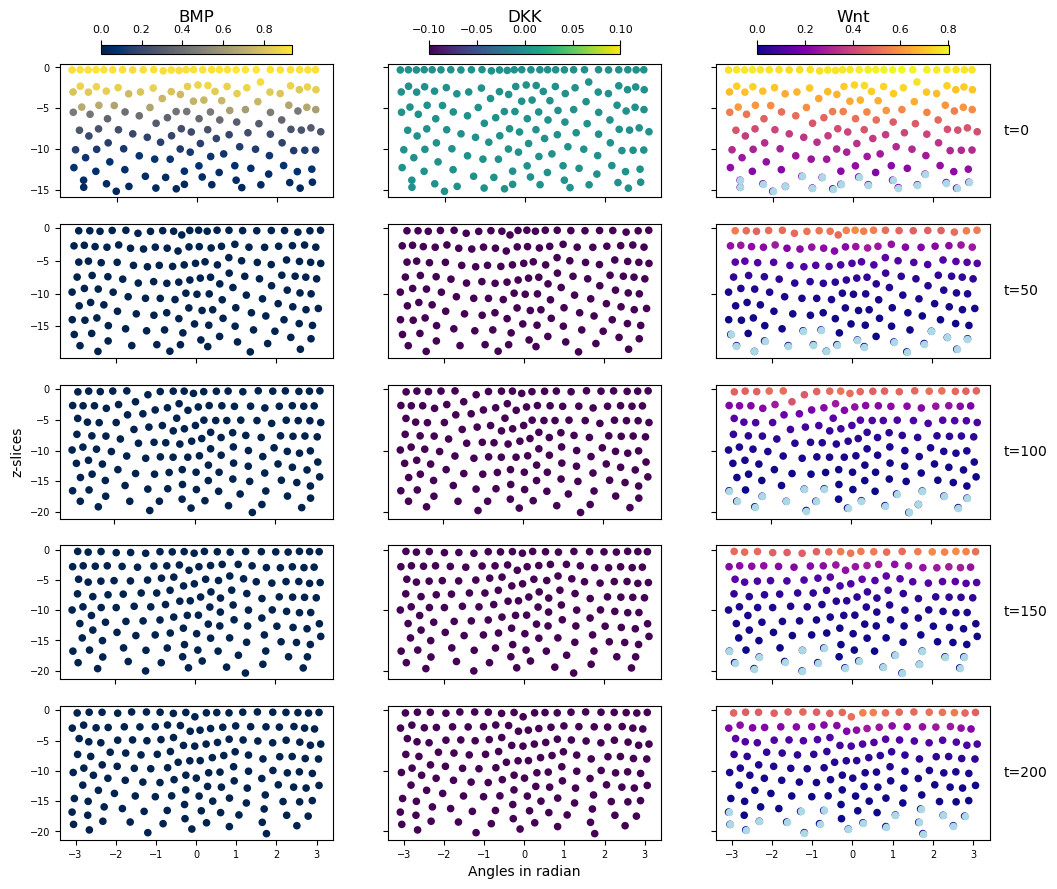

In [3]:
file = "datainit_mod.npy"
asys.unwrap_grad3(file,0,False,[0, 50,100, 150, 200],False)



In [4]:
file = "datainit_mod.npy"
asys.animate(file, 2, DVE_type=2, if_w = False, no_morph = 3, cam_angle=(90,0,0), frame_t = 20)